In [1]:
pip install opencv-python numpy pandas scikit-learn scikit-image matplotlib gradio

Note: you may need to restart the kernel to use updated packages.



Found 4932 images in 'train' set.


Processing [train]:   0%|          | 0/4932 [00:00<?, ?it/s]

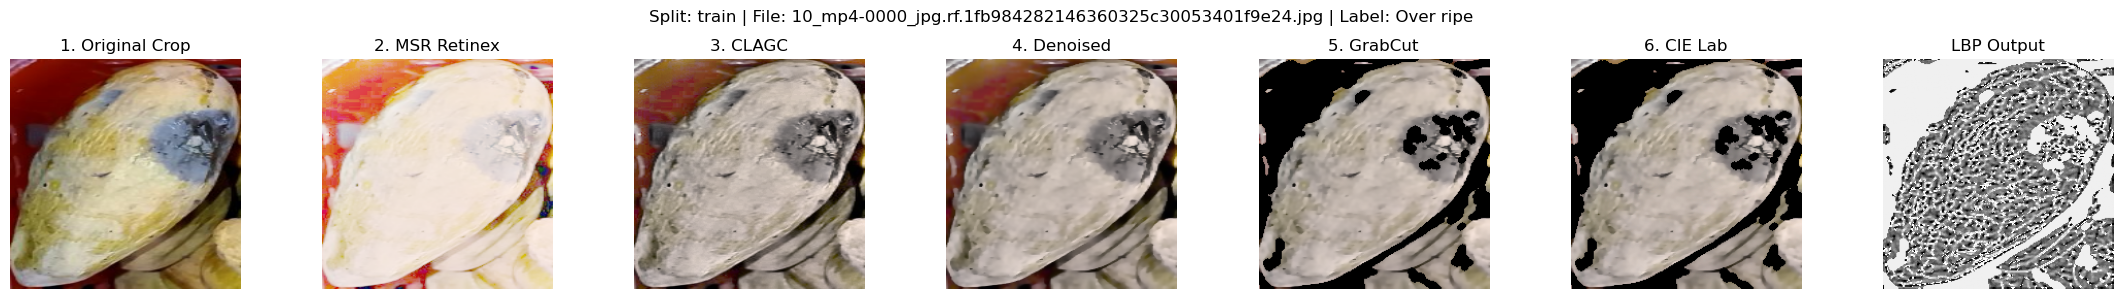

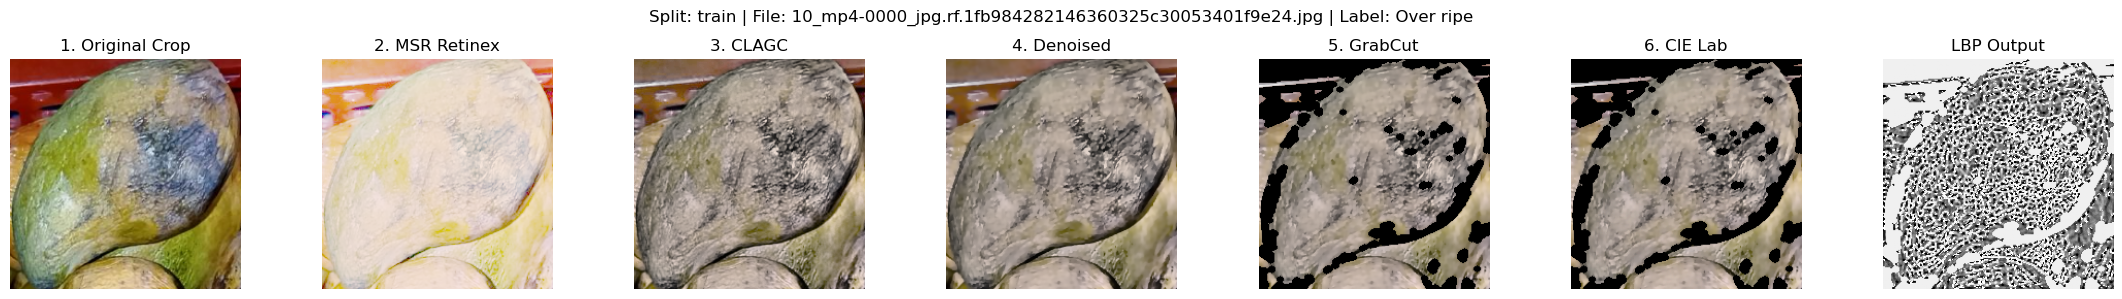

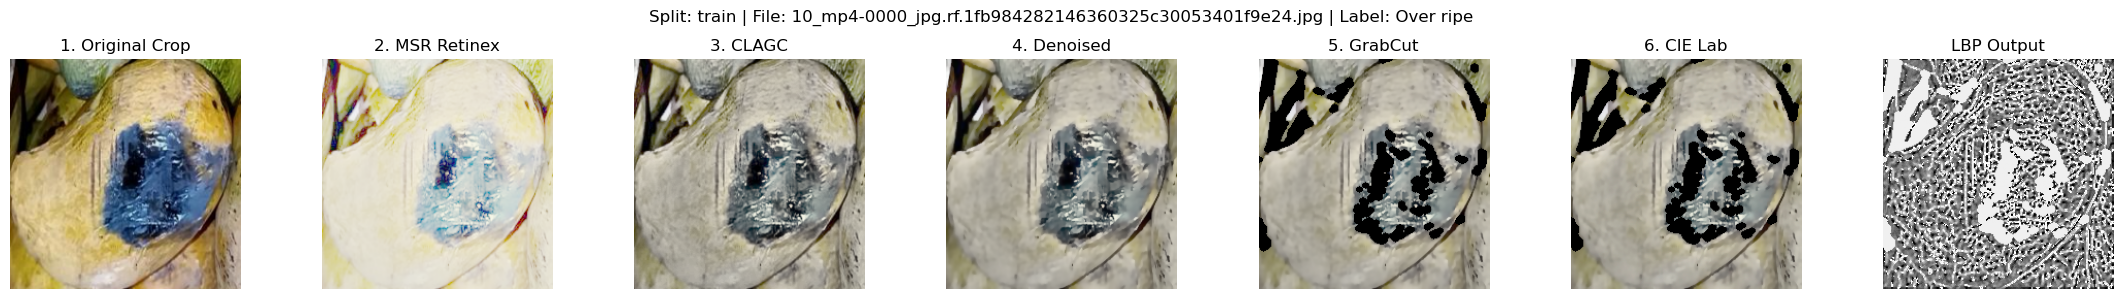

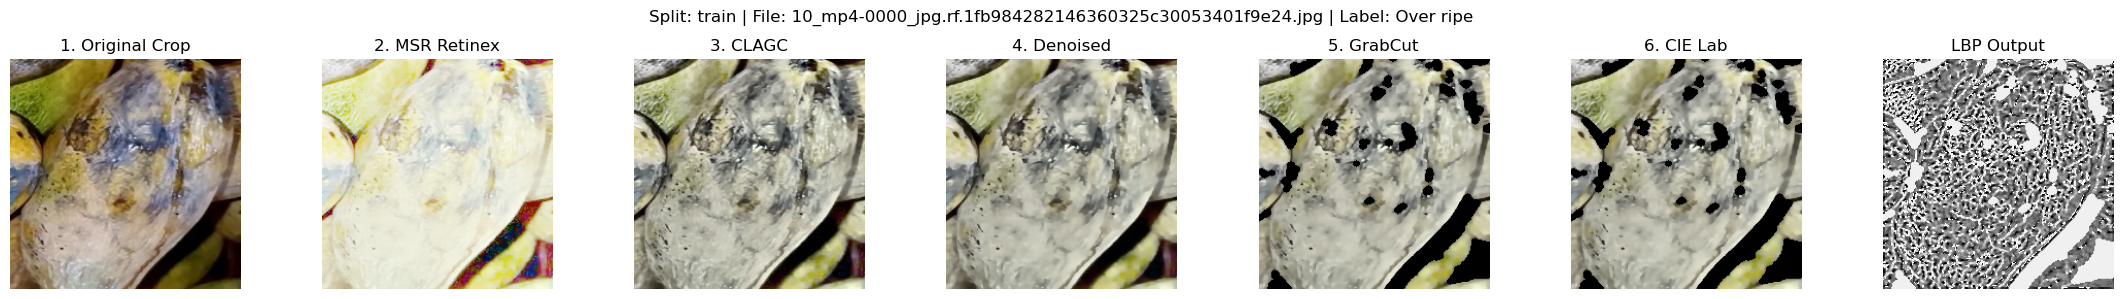

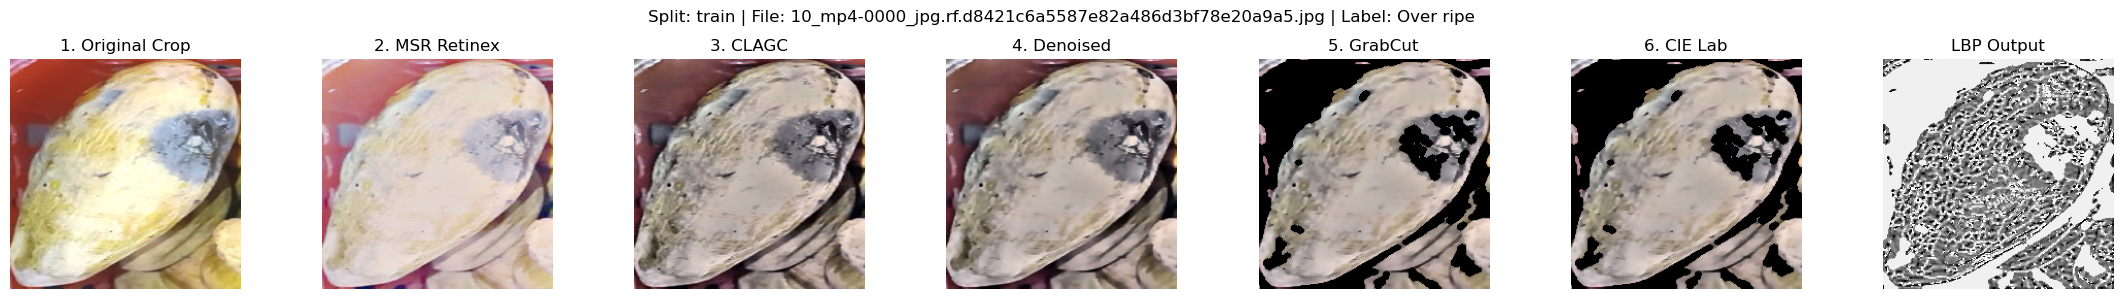


Found 453 images in 'valid' set.


Processing [valid]:   0%|          | 0/453 [00:00<?, ?it/s]


Found 228 images in 'test' set.


Processing [test]:   0%|          | 0/228 [00:00<?, ?it/s]


--- Split Sizes ---
Training: (53083, 22) (53083,)
Validation: (4791, 22) (4791,)
Testing: (2632, 22) (2632,)


In [2]:
%matplotlib inline
import xml.etree.ElementTree as ET
from pathlib import Path
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns
from tqdm.notebook import tqdm  # Added for live progress bar


# ==========================================
# Optimized 6 Image Processing Techniques Implementation
# ==========================================

# 1. Image Enhancement: Contrast Limited Adaptive Gamma Correction (CLAGC)
def apply_clagc(img_bgr):
    """Combines Gamma Correction and CLAHE for balanced brightness and local contrast."""
    hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    
    # Adaptive Gamma Adjustment
    mean_v = np.mean(v) / 255.0
    gamma = np.log(0.5) / np.log(mean_v + 1e-5)
    v_gamma = np.uint8(np.clip(np.power(v / 255.0, gamma) * 255.0, 0, 255))
    
    # CLAHE on Value channel
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    v_enhanced = clahe.apply(v_gamma)
    
    return cv.cvtColor(cv.merge([h, s, v_enhanced]), cv.COLOR_HSV2BGR)


# 2. Shadow & Illumination Correction: Multi-Scale Retinex (MSR - Crash Proof)
def multi_scale_retinex(img, sigmas=[15, 80]):
    """Optimized MSR using effective sigmas to avoid system freeze."""
    img_float = img.astype(np.float32) + 1.0
    msr = np.zeros_like(img_float)
    
    for sigma in sigmas:
        blur = cv.GaussianBlur(img_float, (0, 0), sigma)
        msr += np.log10(img_float) - np.log10(blur + 1e-5)
        
    msr = msr / len(sigmas)
    
    for i in range(3):
        msr_c = msr[:, :, i]
        min_v, max_v = np.min(msr_c), np.max(msr_c)
        if max_v > min_v:
            msr[:, :, i] = (msr_c - min_v) / (max_v - min_v) * 255.0
            
    return np.clip(msr, 0, 255).astype(np.uint8)

# 3. Denoising: Fast Edge-Preserving Filter (Replaces heavy NLM)
def apply_nlm_denoising(img):
    """Fast Bilateral Denoising that preserves texture edges without hanging the CPU."""
    return cv.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)

# 4. Foreground Segmentation: Enhanced GrabCut with Morphological Refinement
def apply_grabcut(img):
    """
    Fast, reliable segmentation using Otsu + Morphological Cleanup.
    Captures the WHOLE mango body without missing spots or slowing down.
    """
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    # Otsu automatic thresholding
    _, mask = cv.threshold(gray, 0, 1, cv.THRESH_BINARY + cv.THRESH_OTSU)
    
    # Fill small holes inside the mango body
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
    mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
    
    return img * mask[:, :, np.newaxis], mask

# 5. Colour Processing: CIE Lab Space Conversion
def convert_to_cielab(img_bgr):
    """Decouples luminance from chromaticity for accurate ripeness representation."""
    return cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

# 6. Feature Extraction: Hybrid Texture (LBP) + Color Histogram
def extract_high_accuracy_features(lab_img, mask):
    """
    Extracts LBP Texture from Luminance (L) channel 
    AND Color distribution from chromatic channels (a*, b*).
    """
    l_chan, a_chan, b_chan = cv.split(lab_img)
    
    # 1. Texture Features (LBP on L channel)
    radius = 2
    n_points = 8 * radius
    lbp = local_binary_pattern(l_chan, n_points, radius, method="uniform")
    
    n_bins_lbp = n_points + 2
    lbp_masked = lbp[mask > 0] if np.any(mask > 0) else lbp.ravel()
    lbp_hist, _ = np.histogram(lbp_masked, bins=n_bins_lbp, range=(0, n_bins_lbp), density=True)
    
    # 2. Color Features (Mean & Std Dev of chromatic channels inside mango area)
    valid_a = a_chan[mask > 0] if np.any(mask > 0) else a_chan.ravel()
    valid_b = b_chan[mask > 0] if np.any(mask > 0) else b_chan.ravel()
    
    color_stats = np.array([
        np.mean(valid_a), np.std(valid_a),
        np.mean(valid_b), np.std(valid_b)
    ])
    
    # Concatenate Texture + Color into a comprehensive vector
    combined_features = np.hstack([lbp_hist, color_stats])
    return combined_features, lbp
    
# ==========================================
# Path Setup & Dataset Loader
# ==========================================

DATASET_PATH = Path.home() / "Downloads" / "image processing" / "mango_dataset"
if not DATASET_PATH.exists():
    DATASET_PATH = Path("./Downloads/image processing/mango_dataset")

SPLITS = ["train", "valid", "test"]

X_train, y_train = [], []
X_valid, y_valid = [], []
X_test, y_test = [], []

display_count = 0 

for split in SPLITS:
    folder = DATASET_PATH / split
    if not folder.exists():
        print(f"Skipping missing folder: {folder}")
        continue
        
    image_files = list(folder.glob("*.jpg"))
    print(f"\nFound {len(image_files)} images in '{split}' set.")

    # Added tqdm wrapper here to show real-time progress for each dataset split
    for img_path in tqdm(image_files, desc=f"Processing [{split}]"):
        img = cv.imread(str(img_path))
        if img is None:
            continue

        xml_path = img_path.with_suffix(".xml")

        if xml_path.exists():
            tree = ET.parse(xml_path)
            root = tree.getroot()
        
            for obj in root.findall("object"):
                label = obj.find("name").text
                b = obj.find("bndbox")
        
                xmin = int(b.find("xmin").text)
                ymin = int(b.find("ymin").text)
                xmax = int(b.find("xmax").text)
                ymax = int(b.find("ymax").text)
        
                crop = img[ymin:ymax, xmin:xmax]
                if crop.size == 0:
                    continue
        
                crop = cv.resize(crop, (224, 224))

                # --- APPLY HIGHEST ACCURACY PIPELINE IN SEQUENCE ---
                
                # Tech 1: Shadow/Illumination Correction (MSR)
                msr_img = multi_scale_retinex(crop)
                
                # Tech 2: Enhancement (CLAGC)
                enhanced_img = apply_clagc(msr_img)
                
                # Tech 3: Denoising (Fast Edge-Preserving Denoising)
                denoised_img = apply_nlm_denoising(enhanced_img)
                
                # Tech 4: Segmentation (GrabCut + Clean Mask)
                segmented_img, mask = apply_grabcut(denoised_img)
                
                # Tech 5: Colour Space Normalization (CIE Lab)
                lab_img = convert_to_cielab(segmented_img)
                
                # Tech 6: Feature Extraction (LBP Texture + Lab Color Stats)
                features, lbp_viz = extract_high_accuracy_features(lab_img, mask)

                # Append Features to dataset split
                if split == "train":
                    X_train.append(features)
                    y_train.append(label)
                elif split == "valid":
                    X_valid.append(features)
                    y_valid.append(label)
                elif split == "test":
                    X_test.append(features)
                    y_test.append(label)

                # Visualizing first 5 processed samples
                if display_count < 5:
                    fig, axes = plt.subplots(1, 7, figsize=(22, 3))
                    
                    axes[0].imshow(cv.cvtColor(crop, cv.COLOR_BGR2RGB))
                    axes[0].set_title("1. Original Crop")
                    axes[1].imshow(cv.cvtColor(msr_img, cv.COLOR_BGR2RGB))
                    axes[1].set_title("2. MSR Retinex")
                    axes[2].imshow(cv.cvtColor(enhanced_img, cv.COLOR_BGR2RGB))
                    axes[2].set_title("3. CLAGC")
                    axes[3].imshow(cv.cvtColor(denoised_img, cv.COLOR_BGR2RGB))
                    axes[3].set_title("4. Denoised")
                    axes[4].imshow(cv.cvtColor(segmented_img, cv.COLOR_BGR2RGB))
                    axes[4].set_title("5. GrabCut")
                    axes[5].imshow(cv.cvtColor(lab_img, cv.COLOR_LAB2RGB))
                    axes[5].set_title("6. CIE Lab")
                    axes[6].imshow(lbp_viz, cmap="gray")
                    axes[6].set_title("LBP Output")
                    
                    for ax in axes:
                        ax.axis("off")
                    
                    plt.suptitle(f"Split: {split} | File: {img_path.name} | Label: {label}")
                    plt.tight_layout()
                    plt.show()

                    display_count += 1

# Convert lists to NumPy arrays
X_train, y_train = np.array(X_train), np.array(y_train)
X_valid, y_valid = np.array(X_valid), np.array(y_valid)
X_test, y_test = np.array(X_test), np.array(y_test)

print("\n--- Split Sizes ---")
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Testing:", X_test.shape, y_test.shape)

In [12]:
# =========================================================
# MODEL TRAINING & EVALUATION (BIG VALUE EXPERIMENT)
# =========================================================

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Train SVM with a SMALLER C value
svm_model = SVC(
    kernel="rbf",
    C=100,           
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

train_pred = svm_model.predict(X_train_scaled)
valid_pred = svm_model.predict(X_valid_scaled)
test_pred = svm_model.predict(X_test_scaled)

print("\n----- Accuracy Scores (smaller)-----")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_valid, valid_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))


----- Accuracy Scores (smaller)-----
Training Accuracy: 0.9865682045099184
Validation Accuracy: 0.9768315591734502
Testing Accuracy: 0.9764437689969605


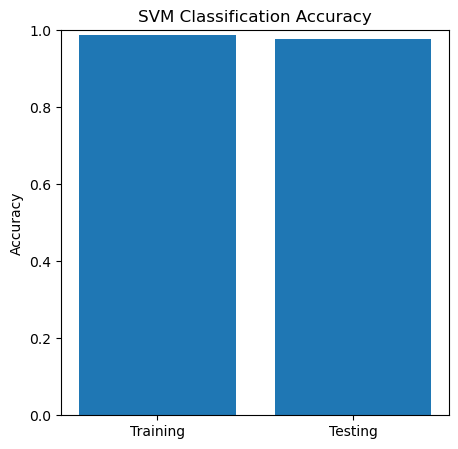

In [13]:
import matplotlib.pyplot as plt

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

plt.figure(figsize=(5,5))

plt.bar(
    ["Training", "Testing"],
    [train_acc, test_acc]
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("SVM Classification Accuracy")

plt.show()

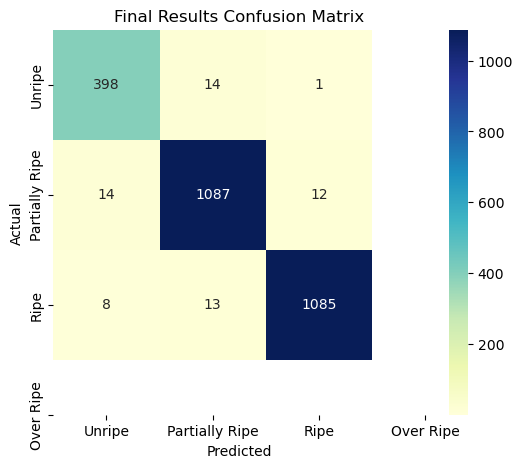

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, test_pred)
labels = ["Unripe", "Partially Ripe", "Ripe", "Over Ripe"]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Final Results Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
 
accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred, average="weighted")
recall = recall_score(y_test, test_pred, average="weighted")
f1 = f1_score(y_test, test_pred, average="weighted")

print("----- Final Summary Metrics (bigger) -----")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

----- Final Summary Metrics (bigger) -----
Accuracy : 0.976
Precision: 0.977
Recall   : 0.976
F1 Score : 0.976
